In [1]:
# 对比 D learning imitate PPO \ D learning without PPO \ traditional PPO (RL)
# system : pendulum

import torch
from torch import nn
from torch.nn import functional as F
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import pickle
from PIL import Image
import os

from systems_and_functions.control_affine_system import ControlAffineSystem
from systems_and_functions.cart_pole_system import CartPole
from systems_and_functions.inverted_pendulum_system import InvertedPendulum

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [5]:
class PolicyNet(nn.Module):
    def __init__(
        self, 
        n_states: int = 2, 
        n_hiddens: int = 16,
        n_actions: int = 1, 
        action_bound: float = 5.0
        # n_states, 
        # n_hiddens,
        # n_actions, 
        # action_bound
    ):
        super(PolicyNet, self).__init__()
        # 环境可以接受的动作最大值
        self.action_bound = action_bound
        self.n_actions = n_actions
        # 只包含一个隐含层
        self.fc1 = nn.Linear(n_states, n_hiddens)
        self.fc2 = nn.Linear(n_hiddens, n_actions + 1)

    # 前向传播
    def forward(self, x):
        x = x.t()
        x = self.fc1(x)  # [b,n_states]-->[b,n_hiddens]
        x = F.relu(x)
        x = self.fc2(x)  # [b,n_hiddens]-->[b,n_actions]
        # x = F.relu(x)
        # x = torch.tanh(x)  # 将数值调整到 [-1,1]
        # u = x * self.action_bound  # 缩放到 [-action_bound, action_bound]
        return x
    
    def Controller(self, x):
        # x = x.t()
        u = self.forward(x).t()[:self.n_actions]
        # u = u * self.action_bound  # 缩放到 [-action_bound, action_bound]
        return u

class LyapunovNet(nn.Module):
    def __init__(
        self,
        n_states:int = 4, 
        n_hiddens:int = 128
    ):
        super(LyapunovNet, self).__init__()
        self.fc1 = nn.Linear(n_states, n_hiddens)
        self.fc2 = nn.Linear(n_hiddens, n_hiddens)
        self.fc3 = nn.Linear(n_hiddens, 2)

    def forward(self, x):
        # x = x.clone().detach().requires_grad_(True)
        s = self.fc1(x)  # -->[b, n_hiddens]
        # s = F.relu(s)
        s = torch.tanh(s)
        s = self.fc2(s)  # -->[b, n_hiddens]
        # s = F.relu(s)
        s = torch.tanh(s)
        V = self.fc3(s)  # -->[b, 1]
        # V = 0.5 * torch.pow(V,2) # semi-positive definite
        return V
    
    def V(self, x):
        return self.forward(x)[:,0]

    def V_with_JV(self, x):
        x = x.clone().detach().requires_grad_(True)
        V = self.forward(x)
        JV = torch.autograd.grad(V, x)
        return V, JV

class DFunctionNet(nn.Module):
    def __init__(
        self,
        n_states:int = 4, 
        n_hiddens: int = 128, 
        n_actions: int = 2
    ):
        super(DFunctionNet, self).__init__()
        self.fc1 = nn.Linear(n_states + n_actions, n_hiddens)
        self.fc2 = nn.Linear(n_hiddens, n_hiddens)
        self.fc3 = nn.Linear(n_hiddens, 2)

    # 前向传播
    def forward(self, x, a):
        # 拼接状态和动作
        cat = torch.cat([x, a], dim=1)  # [b, n_states + n_actions]
        x = self.fc1(cat)  # -->[b, n_hiddens]
        x = F.relu(x)
        x = self.fc2(x)  # -->[b, n_hiddens]
        x = F.relu(x)
        x = self.fc3(x)  # -->[b, 1]
        return x

    def D(self, x, a):
        return self.forward(x, a)[:,0]

In [6]:
# D learning 类，包含了D learning中的各种功能函数 
# TODO: 类暂未完成
class DlearningProcess:
    def __init__(
        self, 
        system: ControlAffineSystem,
        actor_bound: float = 5.0,
        n_hiddens_policy: int = 16,
        n_hiddens_lyapunov: int = 128,
        n_hiddens_dfunction: int = 128,
        actor_lr: float = 0.01,
        lyapunov_lr: float = 0.01,
        dfunction_lr: float = 0.01,
        sigma: float = 0.5,
        tau: float = 0.1,
        device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'),
    ):
        # 属性分配
        self.system = system # 动力学系统
        self.sigma = sigma # 噪声标准差
        self.tau = tau # 软更新权重
        self.n_states = self.system.state_dims()
        self.n_actions = self.system.control_dims()
        self.device = device
        # 训练网络
        self.actor = PolicyNet(self.system.state_dims(), n_hiddens_policy, self.system.control_dims(), actor_bound).to(device)
        self.lyapunov = LyapunovNet(self.system.state_dims(), n_hiddens_lyapunov).to(device)
        self.dfunction = DFunctionNet(self.system.state_dims(), n_hiddens_dfunction, self.system.control_dims()).to(device)
        # 训练网络的优化器
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=actor_lr)
        self.lyapunov_optimizer = torch.optim.Adam(self.lyapunov.parameters(), lr=lyapunov_lr)
        self.dfunction_optimizer = torch.optim.Adam(self.dfunction.parameters(), lr=dfunction_lr)

        # DONE: 初始化神经网络控制器


    def initialize_policy_net(
            self,
            x_train_lim: int = 10,
            x_test_lim: int = 13,
            sample_num: int = 1000,
            iteration: int = 2*10**4,
            lr: float = 1e-4
    ):
        """
        用神经网络拟合专家策略（线性静态状态反馈）
        """
        print('---------------------Initializing Policy------------------------')

        # x = torch.linspace(-x_train_lim, x_train_lim, sample_num, dtype=torch.float)
        # train_data = torch.stack([x] * self.system.state_dims(), dim = 1).to(self.device)

        random_data = [-x_train_lim + torch.rand(400)*2*x_train_lim for _ in range(self.system.state_dims())]
        train_data = torch.stack(random_data, dim=1).to(self.device)
        K = torch.tensor(-self.system.K)
        zero_column = torch.zeros(1, 2)
        K_extended = torch.vstack((K, zero_column)).t().to(self.device)
        labels = train_data @ K_extended
        loss_fn = nn.MSELoss()
        optimizer = torch.optim.SGD(self.actor.parameters(), lr = lr)
        for i in range(iteration):
            optimizer.zero_grad()
            y_train = self.actor(train_data.t())
            loss = loss_fn(y_train, labels)
            # if i % 10000 == 0:
            #     print(f'times {i} - lr {lr} -  loss: {loss.item()}')
            if (i + 1) % 1000 == 0:
                print ('Epoch [{}/{}], Loss: {:.10f}'.format(i + 1, iteration, loss.item()))
            loss.backward()
            optimizer.step()
    
    def sample_training_data_actions(
        #  沿轨迹采样 + 均匀分布采样 
        self,
        sample_trajectory_number: int = 10,
        sample_number_per_trajectory: int = 500,
        sample_radius: int = 15,
        sample_number_in_radius: int = 0,
        invariant_sample: bool = True,
        sample_plot: bool = True,
        the_controller = None, # 指定控制器，默认为ControlAffineSystem自带控制器
        title = "Samples"
    )->torch.Tensor:
        print('---------------------Sampling Training Data---------------------')
        sample_from_trajectory = torch.zeros(sample_trajectory_number*sample_number_per_trajectory,2,2,1).to(self.device)
        sample_from_radius = torch.zeros(sample_number_in_radius,2,2,1).to(self.device)
        theta = np.linspace(0, 2*np.pi, sample_trajectory_number + 1)
        
        # sample in trajectory
        actions = [] # 储存每次采样的控制输入 u 
        for i in range(0, sample_trajectory_number):
            x_0_traj = torch.tensor([[sample_radius*np.cos(theta[i])],[sample_radius*np.sin(theta[i])]],dtype=torch.float).to(self.device)
            [simulate_rk4, u] = self.system.simulate_rk4_include_u(x_0_traj,sample_number_per_trajectory,1,the_controller)
            x = simulate_rk4[:,0].unsqueeze(1)
            x_dot = simulate_rk4[:,1].unsqueeze(1)
            u = u.squeeze()
            sample_from_trajectory[i*sample_number_per_trajectory:(i+1)*sample_number_per_trajectory] = torch.cat((x, x + x_dot*self.system.dt), dim=1)
            actions.append(u) 
        actions= np.array(actions, dtype=np.float32)  # 转换为 NumPy 数组
        actions = torch.tensor(actions, dtype=torch.float32)  # 再转换为 PyTorch 张量
        actions = actions.view(-1)
        
        # sample randomly in radius
        if invariant_sample == True:
            np.random.seed(42)
        theta_ = np.random.uniform(0, 2*np.pi, sample_number_in_radius)
        r_ = np.sqrt(np.random.uniform(0, sample_radius**2, sample_number_in_radius))
        combined_data = zip(theta_, r_)
        i = 0
        for data in combined_data:
            theta__, r__ = data
            x_0_radius = torch.tensor([[r__ * np.cos(theta__)],[r__ * np.sin(theta__)]]).to(self.device)
            one_step_euler = self.system.one_step_euler(x_0_radius,1,the_controller)[1].to(self.device)
            x = one_step_euler[0].unsqueeze(0)
            x_dot = one_step_euler[1].unsqueeze(0)
            sample_from_radius[i] = torch.cat((x, x + x_dot*self.system.dt), dim=0)
            i = i + 1

        if sample_plot == True:
            x1_trajectory = sample_from_trajectory[:,0,0,:].cpu().detach().numpy()
            x2_trajectory = sample_from_trajectory[:,0,1,:].cpu().detach().numpy()
            plt.scatter(x1_trajectory, x2_trajectory, s=10, alpha=0.5, c='c', label='sample_from_trajectory')

            x1_radius = sample_from_radius[:,0,0,:].cpu().detach().numpy()
            x2_radius = sample_from_radius[:,0,1,:].cpu().detach().numpy()
            plt.scatter(x1_radius, x2_radius, s=10, alpha=0.5, c='g', label='sample_from_radius')
            ax = plt.gca()
            ax.set_aspect(1)
            plt.xlabel('x1')
            plt.ylabel('x2')
            plt.title(title)
            plt.legend()
            plt.grid(True)
            plt.show()

        sample_data = torch.cat((sample_from_trajectory,sample_from_radius),dim=0).to(self.device)
        return sample_data, actions
    
    
    def sample_training_data(
        #  沿轨迹采样 + 均匀分布采样 
        self,
        sample_trajectory_number: int = 10,
        sample_number_per_trajectory: int = 500,
        sample_radius: int = 15,
        sample_number_in_radius: int = 0,
        invariant_sample: bool = True,
        sample_plot: bool = True,
        the_controller = None, # 指定控制器，默认为ControlAffineSystem自带控制器
        title = "Samples"
    )->torch.Tensor:
        print('---------------------Sampling Training Data---------------------')
        """
        sample training data
        data content: x_i, x_dot_i, controller_params
        sample strategy: data set is composed of two parts: 
            samples from trajectory;
            samples from random state;
            (if invariant_sample is true, random state point is Unchanging) 
        """
        sample_from_trajectory = torch.zeros(sample_trajectory_number*sample_number_per_trajectory,2,2,1).to(self.device)
        sample_from_radius = torch.zeros(sample_number_in_radius,2,2,1).to(self.device)
        theta = np.linspace(0, 2*np.pi, sample_trajectory_number + 1)
        
        # sample in trajectory
        for i in range(0, sample_trajectory_number):
            x_0_traj = torch.tensor([[sample_radius*np.cos(theta[i])],[sample_radius*np.sin(theta[i])]],dtype=torch.float).to(self.device)
            simulate_rk4 = self.system.simulate_rk4(x_0_traj,sample_number_per_trajectory,1,the_controller)
            x = simulate_rk4[:,0].unsqueeze(1)
            x_dot = simulate_rk4[:,1].unsqueeze(1)
            sample_from_trajectory[i*sample_number_per_trajectory:(i+1)*sample_number_per_trajectory] = torch.cat((x, x + x_dot*self.system.dt), dim=1)

        # sample randomly in radius
        if invariant_sample == True:
            np.random.seed(42)
        theta_ = np.random.uniform(0, 2*np.pi, sample_number_in_radius)
        r_ = np.sqrt(np.random.uniform(0, sample_radius**2, sample_number_in_radius))
        combined_data = zip(theta_, r_)
        i = 0
        for data in combined_data:
            theta__, r__ = data
            x_0_radius = torch.tensor([[r__ * np.cos(theta__)],[r__ * np.sin(theta__)]]).to(self.device)
            one_step_euler = self.system.one_step_euler(x_0_radius,1,the_controller)[1].to(self.device)
            x = one_step_euler[0].unsqueeze(0)
            x_dot = one_step_euler[1].unsqueeze(0)
            sample_from_radius[i] = torch.cat((x, x + x_dot*self.system.dt), dim=0)
            i = i + 1

        if sample_plot == True:
            x1_trajectory = sample_from_trajectory[:,0,0,:].cpu().detach().numpy()
            x2_trajectory = sample_from_trajectory[:,0,1,:].cpu().detach().numpy()
            plt.figure(figsize=(8, 6))
            # plt.scatter(x1_trajectory, x2_trajectory, s=10, alpha=0.5, c='c', label='sample_from_trajectory')
            plt.scatter(x1_trajectory, x2_trajectory, s=10, alpha=0.5, c='c', label='Sample from trajectories')
            for i in range(0, len(x1_trajectory), sample_number_per_trajectory):
                # plt.scatter(x1_trajectory[i], x2_trajectory[i], s=30, alpha=0.5, c='blue', marker='o', label='Initial States'if i == 0 else '')
                plt.scatter(x1_trajectory[i+199], x2_trajectory[i+199], s=30, alpha=0.8, c='red', marker='*', label='Stable  States'if i == 0 else '')
            

            x1_radius = sample_from_radius[:,0,0,:].cpu().detach().numpy()
            x2_radius = sample_from_radius[:,0,1,:].cpu().detach().numpy()
            # plt.scatter(x1_radius, x2_radius, s=10, alpha=0.5, c='g', label='sample_from_radius')
            plt.scatter(x1_radius, x2_radius, s=10, alpha=0.5, c='g')
            ax = plt.gca()
            ax.set_aspect(1)
            plt.xlabel('x1')
            plt.ylabel('x2')
            plt.title(title)
            plt.legend()
            plt.grid(True)
            plt.xlim(-3, 3)
            plt.show()

        sample_data = torch.cat((sample_from_trajectory,sample_from_radius),dim=0).to(self.device)
        return sample_data

    
    def learn_V_LQF(
        self,
        sample_data,
        plot_lyapuonv: bool = True
    ):
        """
        learn a V(x) by constraining V(x)>=0, V_dot(x)<=0
        """
        print('--------------------------Learning V--------------------------')
        sample_data = sample_data.cpu().detach().numpy()
        P = cp.Variable((self.system.state_dims(), self.system.state_dims()))
        eta = cp.Variable()
        
        constraints = [P.T == P, eta>=0]
        for i in range(sample_data.shape[0]):
            xi = sample_data[i][0]
            xi_dot = (sample_data[i][1]-sample_data[i][0])/self.system.dt
            constraints.append(xi.T@P@xi>=0)
            constraints.append(xi.T@P@xi_dot+xi_dot.T@P@xi<=-eta*np.linalg.norm(xi)**2)

        objective = cp.Minimize(-eta)
        problem = cp.Problem(objective, constraints)
        # 求解优化问题
        problem.solve()
        print("status:",problem.status)
        # print("optimal value",problem.value)
        # 输出解
        print("var eta (eta should be positive):", eta.value)
        print("var P:", P.value)
        self.P = torch.tensor(P.value).float()

        if plot_lyapuonv:
            xlim = 5
            ylim = 5
            print('-----------------------Plotting Lyapunov-----------------------')
            x = np.linspace(-xlim, xlim, 100)
            y = np.linspace(-ylim, ylim, 100)
            X, Y = np.meshgrid(x, y)
            grid = np.stack([X, Y], axis=-1)
            P = self.P
            Z = np.einsum('...i,ij,...j->...', grid, P, grid)

            plt.figure(figsize=(8, 6))
            plt.contourf(X, Y, Z, levels=25, cmap='RdBu')
            plt.colorbar(label='Lyapunov Function')
            plt.xlabel(r"$\mathregular{x_{1}}$")
            plt.ylabel(r"$\mathregular{x_{2}}$")
            plt.title('Lyapunov Function Contour Plot')
            plt.show()


    def V_value_P_batch(self, x: torch.Tensor):
        """
        x:[sample num, value, n dims]
        return [sumple num, value]
        """
        P = self.P.to(self.device)
        xP = torch.matmul(x, P)
        quadratic_form = torch.sum(xP * x, dim=1, keepdim=True)

        return quadratic_form


    def initialize_lyapunov_net(
            self,
            x_train_lim: int = 15,
            x_test_lim: int = 13,
            sample_num: int = 1000,
            iteration: int = 5*10**4,
            lr: float = 1e-3,
            plot_loss: bool = True,
            plot_lyapuonv: bool = True
    ):
        """
        用lyapunov_net拟合二次型lyapunov作为初始化
        """
        print('--------------------Initializing Lyapunov---------------------')
        random_data = [-x_train_lim + torch.rand(sample_num) * 2 * x_train_lim for _ in range(self.system.state_dims())]
        training_data = torch.stack(random_data, dim=1).to(self.device)
        V_value_P = self.V_value_P_batch(training_data)
        labels = torch.cat([V_value_P, torch.zeros(V_value_P.shape[0],1).to(self.device)], dim=1).to(self.device)

        loss_fn = nn.MSELoss()
        # optimizer = self.lyapunov_optimizer
        # optimizer = torch.optim.Adam(self.lyapunov.parameters(), lr = lr)
        optimizer = torch.optim.Adam(self.lyapunov.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-8, weight_decay=0)
        loss_values = []
        for i in range(iteration):
            optimizer.zero_grad()
            y_train = self.lyapunov(training_data)
            param_squares = [p ** 2 for p in self.lyapunov.parameters()]
            param_sum_square = sum(torch.sum(p) for p in param_squares)
            loss = loss_fn(y_train, labels) + 0.01 * param_sum_square
            # if i % 10000 == 0:
            #     print(f'times {i} - lr {lr} -  loss: {loss.item()}')
            loss_values.append(loss.item())
            if (i + 1) % 1000 == 0:
                print ('Epoch [{}/{}], Loss: {:.10f}'.format(i + 1, iteration, loss.item()))
            loss.backward()
            optimizer.step()
        
        if plot_loss:
            plt.figure(figsize=(10, 5))
            plt.plot(loss_values, label='Loss')
            plt.xlabel('Iteration')
            plt.ylabel('Loss')
            plt.title('Initializing V Loss')
            plt.legend() 
            plt.show()

        if plot_lyapuonv:
            self.plot_contour(5, 5, 'Lyapunov')

    # DONE: learn a NN Lyapunov Candidate using discrete data
    def learn_V_LNN(
        self,
        sample_data,
        iteration: int = 3*10**3,
        plot_loss: bool = True,
        plot_lyapuonv: bool = True,
        lr: float = 1e-4
    ):
        dt = self.system.dt
        print('--------------------------Learning V--------------------------')
        sample_data = sample_data.detach().clone()
        # DONE: using sample_data = sample_data.detach().clone()
        # RuntimeError: Trying to backward through the graph a second time 
        # (or directly access saved tensors after they have already been freed).
        # Saved intermediate values of the graph are freed when you call 
        # .backward() or autograd.grad(). Specify retain_graph=True 
        # if you need to backward through the graph a second time or 
        # if you need to access saved tensors after calling backward

        # sample initialize ([100, 2, 2, 1])
        # dim1: sample index
        # dim2: x  x'
        # dim3: x1 x2
        # dim4: value

        N = sample_data.shape[0]
        s = sample_data[:,0].permute(0, 2, 1).squeeze(1)
        s_ = sample_data[:,1].permute(0, 2, 1).squeeze(1)
        s0 = torch.tensor([[0.],[0.]]).t().to(device)
        optimizer = torch.optim.Adam(self.lyapunov.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-8, weight_decay=0)
        # self.lyapunov_optimizer
        loss_values = []

        # 扩大 ROA
        data = sample_data[:,0]
        result = []
        for j in range(data.shape[0]):
            row_sum = torch.sum(data[j,:]**2)
            f = torch.sqrt(row_sum)
            result.append(f.item())  # 将结果添加到列表中，使用item()获取标量值
        Circle_Tuning = torch.tensor(result)
        Circle_Tuning = Circle_Tuning.squeeze()

        for i in range(iteration):
            L0 = self.lyapunov.V(s0)
            Ls = self.lyapunov.V(s)
            Ls_ = self.lyapunov.V(s_)
            dL = (Ls_ - Ls) / dt
            SND = torch.sum(F.relu(dL+0.5))
            PD = torch.sum(F.relu(-Ls))

            # param_squares = [p ** 2 for p in self.lyapunov.parameters()]
            # param_sum_square = sum(torch.sum(p) for p in param_squares)
            # loss = L0**2 + (PD + SND) + 0.01 * param_sum_square
            # 2.2*((Circle_Tuning-6*Ls_squeezed).pow(2)).mean() 扩大 ROA
            Ls_squeezed = Ls.squeeze()
            loss = (PD + 1.5 * SND)/N + 1.2* L0.pow(2) + 2.2*((Circle_Tuning-6*Ls_squeezed).pow(2)).mean()
         
        
            loss.backward(retain_graph = True)  # 计算损失的梯度
            with torch.no_grad(): 
                optimizer.step()                # 根据梯度更新模型参数
                optimizer.zero_grad()           # 清除梯度，准备下一个迭代
            loss_values.append(loss.item())
            if (i + 1) % 1000 == 0:
                print ('Epoch [{}/{}], Loss: {:.10f}'.format(i + 1, iteration, loss.item()))

        if plot_loss:
            plt.figure(figsize=(10, 5))
            plt.plot(loss_values, label='Loss')
            plt.xlabel('Iteration')
            plt.ylabel('Loss')
            plt.title('Training V Loss')
            plt.legend() 
            plt.show()
        
        if plot_lyapuonv:
            self.plot_contour()
        print('L0:{}, PD:{}, torch.sum(F.relu(dL)):{}'.format(L0, PD, torch.sum(F.relu(dL)) ))
    
    def plot_contour(
        self,
        xlim = 5,
        ylim = 5,
        select = 'Lyapunov'
    ):
        print('-----------------------Plotting Lyapunov-----------------------')
        x = np.linspace(-xlim, xlim, 100)
        y = np.linspace(-ylim, ylim, 100)
        X, Y = np.meshgrid(x, y)
        Z = np.zeros(X.shape)
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
            # 将X和Y的值合并成一个二维列向量
                xy = torch.tensor([[X[i, j], Y[i, j]]], dtype=torch.float32).to(device)
                # 计算Lyapunov函数值
                if select == 'Dfunction':
                    Z[i, j] = self.dfunction.D(xy,self.actor.Controller(xy.t())).item()
                else:
                    Z[i, j] = self.lyapunov.V(xy).item()

        plt.figure(figsize=(8, 6))
        plt.contourf(X, Y, Z, levels=25, cmap='RdBu')
        plt.colorbar(label='Function Value')
        plt.xlabel(r"$\mathregular{x_{1}}$")
        plt.ylabel(r"$\mathregular{x_{2}}$")
        plt.title(select +' Function Contour Plot')
        plt.show()

    def learn_D_DNN(
        self,
        sample_data,
        iteration: int = 10**4,
        plot_loss: bool = True,
        plot_dfunction: bool = True,
        lr: float = 1e-4
    ):
        dt = self.system.dt
        print('--------------------------Learning D--------------------------')
        sample_data = sample_data.detach().clone()
        N = sample_data.shape[0]
        s = sample_data[:,0].permute(0, 2, 1)
        s_ = sample_data[:,1].permute(0, 2, 1)
        s0 = torch.tensor([[0.],[0.]]).to(device)
        a0 = self.actor.Controller(s0)
        Ls = self.lyapunov(s)
        Ls_ = self.lyapunov(s_)
        dL = ((Ls_ - Ls) / dt).squeeze(1)
        print(dL.shape)
        a = self.actor.Controller(s.squeeze(1).t()).t()
        # optimizer = self.dfunction_optimizer
        optimizer = torch.optim.Adam(self.dfunction.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-8, weight_decay=0)
        loss_values = []
        loss_fn = nn.MSELoss()
        for i in range(iteration):
            D0 = self.dfunction.D(s0.t(), a0)
            DV_ext = self.dfunction(s.squeeze(1),a)
            DV = self.dfunction.D(s.squeeze(1),a)
            param_squares = [p ** 2 for p in self.dfunction.parameters()]
            param_sum_square = sum(torch.sum(p) for p in param_squares)
            loss = torch.sum(loss_fn(dL, DV_ext)) + torch.sum(F.relu(DV)) + D0**2 + 0.01 * param_sum_square
            loss.backward(retain_graph = True)
            with torch.no_grad(): 
                optimizer.step()
                optimizer.zero_grad()
            loss_values.append(loss.item())
            if (i + 1) % 1000 == 0:
                print ('Epoch [{}/{}], Loss: {:.10f}'.format(i + 1, iteration, loss.item()))
        
        if plot_loss:
            plt.figure(figsize=(10, 5))
            plt.plot(loss_values, label='Loss')
            plt.xlabel('Iteration')
            plt.ylabel('Loss')
            plt.title('Training D Loss')
            plt.legend()
            plt.show()
        
        if plot_dfunction:
            self.plot_contour(select='Dfunction')
        print('torch.sum(loss_fn(dL, DV_ext)):{}, torch.sum(F.relu(DV)):{}, D0:{}'.format(torch.sum(loss_fn(dL, DV_ext)),torch.sum(F.relu(DV)),D0))

    def upper_bound_loss(self, output, K0):
        positive_penalty = torch.sum(torch.relu(output + 0.1))
        control_effort_penalty = torch.sum(self.Learned_K**2)
        upper_bound = torch.max(output, dim=0).values
        control_deviation_penalty = torch.sum((self.Learned_K - K0)**2)
        # print('upper_bound:{}, positive_penalty:{}'.format(upper_bound, positive_penalty))
        return upper_bound + positive_penalty + control_effort_penalty*0 + control_deviation_penalty*0
    
    def mean_variance_loss(self,output):
        positive_penalty = torch.sum(torch.relu(output))
        mean = torch.mean(output)
        variance = torch.var(output)
        # print('Mean:{}, Variance:{}'.format(mean, variance))
        return mean + variance*0.1 + positive_penalty*1000

    def upper_bound_mean_variance_loss(self,output,temp):
        """
        """
        positive_penalty = torch.sum(torch.relu(output))
        # upper_bound = torch.max(output, dim=0).values
        upper_bound = torch.max(temp, dim=0).values
        mean = torch.mean(output)
        variance = torch.var(output)
        return upper_bound*100 + mean*10 + variance*0 + positive_penalty*1000

    # TODO: 策略改进
    def policy_improvement(
        self,
        sample_data,
        iteration: int = 10**4,
        plot_loss: bool = True,
        lr: float = 1e-4,
    ):
        print('----------------------Improveing Policy-----------------------')
        sample_data = sample_data.detach().clone()
        N = sample_data.shape[0]
        s = sample_data[:,0].permute(0, 2, 1).squeeze(1)
        # a = self.actor.Controller(s.t()).t()
        # DV = self.dfunction.D(s,a)
        # optimizer = self.actor_optimizer
        optimizer = torch.optim.Adam(self.actor.parameters(), lr=lr, betas=(0.9, 0.999), eps=1e-8, weight_decay=0)
        loss_values = []
        

        for i in range(iteration):
            a_new = self.actor.Controller(s.t()).t()
            DV = self.dfunction.D(s.squeeze(1),a_new)
      
            s_squared = torch.pow(s, 2)
            s_sum = torch.sum(s_squared, dim=1, keepdim=True) 
            s_sum = s_sum.squeeze()

            # 检查s_sum中是否有元素为0
            zero_indices = (s_sum == 0)
            # 将为0的元素设置为10^-6
            s_sum[zero_indices] = 1e-6
            
            DV_s = DV / s_sum
        
            param_squares = [p ** 2 for p in self.actor.parameters()]
            param_sum_square = sum(torch.sum(p) for p in param_squares)
            loss = self.upper_bound_mean_variance_loss(DV,DV_s) + 0.01 * param_sum_square
            loss.backward(retain_graph = True)

            with torch.no_grad(): 
                optimizer.step()
                optimizer.zero_grad()
            loss_values.append(loss.item())

            
            if (i + 1) % 1000 == 0:
                print ('Epoch [{}/{}], Loss: {:.10f}'.format(i + 1, iteration, loss.item()))

        if plot_loss:
            plt.figure(figsize=(10, 5))
            plt.plot(loss_values, label='Loss')
            plt.xlabel('Iteration')
            plt.ylabel('Loss')
            plt.title('Policy Improvement Loss')
            plt.legend()
            plt.show()


    def plot_contour_lyapunov(
        self,
        xlim=5,
        ylim=5,
        lyapunov=None,
        title=''
    ):
        print('-----------------------Plotting Lyapunov-----------------------')
        x = np.linspace(-xlim, xlim, 100)
        y = np.linspace(-ylim, ylim, 100)
        X, Y = np.meshgrid(x, y)
        Z = np.zeros(X.shape)
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                xy = torch.tensor([[X[i, j], Y[i, j]]], dtype=torch.float32).to(device)  # Assuming device handling elsewhere
                Z[i, j] = lyapunov.V(xy).item()  # Compute Lyapunov function value

        plt.figure(figsize=(8, 6))
        # Plot contour plot
        levels = np.linspace(np.min(Z), np.max(Z), 20)
        plt.contourf(X, Y, Z, levels=levels, cmap='viridis')
        plt.xlabel(r"$\mathregular{\theta}(rad)$")
        plt.ylabel(r"$\mathregular{\dot{\theta}}(rad/s)$")
        plt.title(title)
        # Plot attraction region where V(x, y) <= 0
        plt.contour(X, Y, Z, levels=[0], colors='blue', linestyles='dashed')
        plt.show()
        
    def plot_contour_lyapunov_3D(
        self,
        xlim=5,
        ylim=5,
        lyapunov=None,
        title='Lyapunov-function'
    ):
        print('-----------------------Plotting Lyapunov-----------------------')
        x = np.linspace(-xlim, xlim, 100)
        y = np.linspace(-ylim, ylim, 100)
        X, Y = np.meshgrid(x, y)
        Z = np.zeros(X.shape)
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                xy = torch.tensor([[X[i, j], Y[i, j]]], dtype=torch.float32).to(device)  # Assuming device handling elsewhere
                Z[i, j] = max(lyapunov.V(xy).item(), 0)  # Compute Lyapunov function value

        # 创建 3D 图形
        fig = plt.figure(figsize=(8, 7))
        ax = fig.add_subplot(111, projection='3d')  # 创建 3D 坐标系

        # 绘制 3D 曲面图
        surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')
        cset = ax.contourf(X, Y, Z, zdir='z', offset=Z.min(), cmap='viridis')
        # fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)  # 更瘦的颜色条
        fig.colorbar(surf, ax=ax,shrink=0.6)
        # 设置坐标轴标签
        ax.set_xlabel(r"$\mathregular{\theta}(rad)$")
        ax.set_ylabel(r"$\mathregular{\dot{\theta}}(rad/s)$")
        ax.set_title(title, y=1,fontsize=12, fontweight='bold')  # 将 y 设置为 0.9，使标题更靠下
        plt.savefig('result/lyapunov.png', dpi=300)
        plt.show()
        

    def plot_contour_dfunction(
            self,
            xlim=5,
            ylim=5,
            dfunction=None,
            Controller=None,
            title='D-function'
        ):
            print('-----------------------Plotting Lyapunov-----------------------')
            x = np.linspace(-xlim, xlim, 100)
            y = np.linspace(-ylim, ylim, 100)
            X, Y = np.meshgrid(x, y)
            Z = np.zeros(X.shape)

            # 获取 dfunction 和 Controller 所在的设备
            device = next(dfunction.parameters()).device  # 假设 dfunction 和 Controller 在同一个设备上

            for i in range(X.shape[0]):
                for j in range(X.shape[1]):
                    xy = torch.tensor([[X[i, j], Y[i, j]]], dtype=torch.float32).to(device)  # 将输入张量移动到与模型相同的设备
                    Z[i, j] = min(dfunction.D(xy, Controller(xy.t())).item(), 0)  # 计算 D 函数值

            plt.figure(figsize=(8, 6))
            # 绘制等高线图
            levels = np.linspace(np.min(Z), np.max(Z), 20)
            plt.contourf(X, Y, Z, levels=levels, cmap='viridis')
            plt.colorbar(label='D-Function Value')
            plt.xlabel(r"$\mathregular{\theta}$")
            plt.ylabel(r"$\mathregular{\dot{\theta}}$")
            plt.title(title)

            # 绘制吸引域边界 D(x, y) <= 0
            plt.contour(X, Y, Z, levels=[0], colors='blue', linestyles='dashed')

            plt.show()
        
    def plot_contour_dfunction_3D(
        self,
        xlim=5,
        ylim=5,
        dfunction=None,
        Controller=None,
        title='D-function'
    ):
        print('-----------------------Plotting Lyapunov-----------------------')
        x = np.linspace(-xlim, xlim, 100)
        y = np.linspace(-ylim, ylim, 100)
        X, Y = np.meshgrid(x, y)
        Z = np.zeros(X.shape)

        # 获取 dfunction 和 Controller 所在的设备
        device = next(dfunction.parameters()).device  # 假设 dfunction 和 Controller 在同一个设备上

        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                xy = torch.tensor([[X[i, j], Y[i, j]]], dtype=torch.float32).to(device)  # 将输入张量移动到与模型相同的设备
                Z[i, j] = min(dfunction.D(xy, Controller(xy.t())).item(), 0)  # 计算 D 函数值

                # 创建 3D 图形
        fig = plt.figure(figsize=(8, 7))
        ax = fig.add_subplot(111, projection='3d')  # 创建 3D 坐标系

        # 绘制 3D 曲面图
        surf = ax.plot_surface(X, Y, Z, cmap='RdBu', edgecolor='none')
        cset = ax.contourf(X, Y, Z, zdir='z', offset=Z.min(), cmap='RdBu')
        # fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)  # 更瘦的颜色条
        fig.colorbar(surf, ax=ax,shrink=0.6)
        # 设置坐标轴标签
        ax.set_xlabel(r"$\mathregular{\theta}(rad)$")
        ax.set_ylabel(r"$\mathregular{\dot{\theta}}(rad/s)$")
        # ax.set_title(title)
        ax.set_title(title, y=1,fontsize=12, fontweight='bold')  # 将 y 设置为 0.9，使标题更靠下
        # plt.savefig('result/dfunction.png', dpi=300)
        plt.show()
        
        
    def plot_phase_portrait_3(
        self, 
        data_sim: torch.Tensor,
        data_sim1: torch.Tensor,
        arrow_on: bool = False,
        title = 'inverted pendulum phase portrait'
    ):
        data_sim = data_sim.cpu().detach().numpy()
        x_sim = data_sim[:, 0, :, :]
        x_dot_sim = data_sim[:, 1, :, :]
        plt.figure()
        
        num = x_sim.shape[0]
        x_value = x_sim[:, 0, 0]
        y_value = x_sim[:, 1, 0]
        plt.figure(figsize=(8, 6))
        plt.scatter(x_value[0], y_value[0], s=30, alpha=0.5, c='blue', marker='o', label='Initial States')
        
        
        if arrow_on:
            interval = 200  # Draw arrows every interval points
            for i in range(0, num, interval):
                x_dot_x = x_dot_sim[i, 0, 0]
                x_dot_y = x_dot_sim[i, 1, 0]
                dx = 2 * x_dot_x / ((x_dot_x ** 2 + x_dot_y ** 2) ** 0.5)
                dy = 2 * x_dot_y / ((x_dot_x ** 2 + x_dot_y ** 2) ** 0.5)
                plt.arrow(x_sim[i, 0, 0], x_sim[i, 1, 0], dx, dy, head_width=3, head_length=4, fc='r', ec='r')
        
        plt.scatter(x_value[num - 1], y_value[num - 1], s=30, alpha=0.8, c='red', marker='*', label='Stable States')

        plt.plot(x_value, y_value, c='c', label='DL-Clip')
        # plt.plot(x_value, y_value, c='c', label='DL-Clip')
        ##########################################################
        data_sim1 = data_sim1.cpu().detach().numpy()
        x_sim1 = data_sim1[:, 0, :, :]
        x_dot_sim1 = data_sim1[:, 1, :, :]
        
        num1 = x_sim1.shape[0]
        x_value1 = x_sim1[:, 0, 0]
        y_value1 = x_sim1[:, 1, 0]
        
        plt.scatter(x_value1[0], y_value1[0], s=30, alpha=0.5, c='blue', marker='o')
        # plt.plot(x_value1, y_value1, c='grey',label='DL-Online')
        plt.plot(x_value1, y_value1, c='black',label='DL-Online')
        
        if arrow_on:
            interval = 200  # Draw arrows every interval points
            for i in range(0, num1, interval):
                x_dot_x1 = x_dot_sim1[i, 0, 0]
                x_dot_y1 = x_dot_sim1[i, 1, 0]
                dx1 = 2 * x_dot_x1 / ((x_dot_x1 ** 2 + x_dot_y1 ** 2) ** 0.5)
                dy1 = 2 * x_dot_y1 / ((x_dot_x1 ** 2 + x_dot_y1 ** 2) ** 0.5)
                plt.arrow(x_sim1[i, 0, 0], x_sim1[i, 1, 0], dx1, dy1, head_width=3, head_length=4, fc='r', ec='r')
        
        plt.scatter(x_value1[num1 - 1], y_value1[num1 - 1], s=30, alpha=0.8, c='red', marker='*')

        ax = plt.gca()
        ax.set_aspect(1)
        plt.xlabel(r"$\mathregular{\theta}$",fontsize ='20')
        plt.ylabel(r"$\mathregular{\dot{\theta}}$",fontsize ='20')
        plt.xlim(-1, 5)
        plt.title(title)
        plt.legend(loc = 'lower right',fontsize ='14')  # Show legend with added line
        # plt.show()
        plt.savefig('result/fig2_c.png')


Controller is involved.
-----------------------Plotting Lyapunov-----------------------


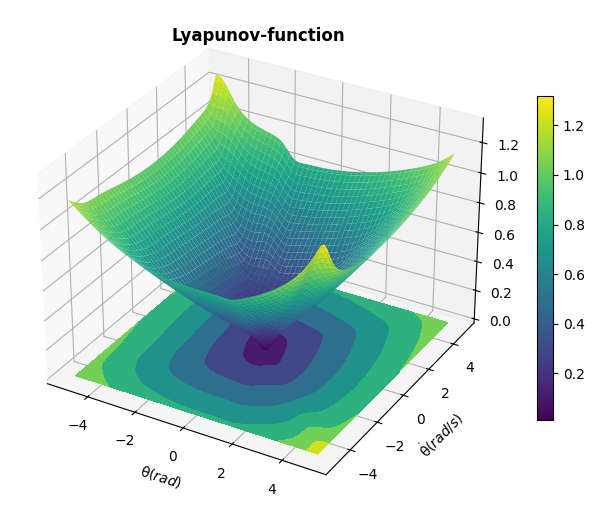

-----------------------Plotting Lyapunov-----------------------


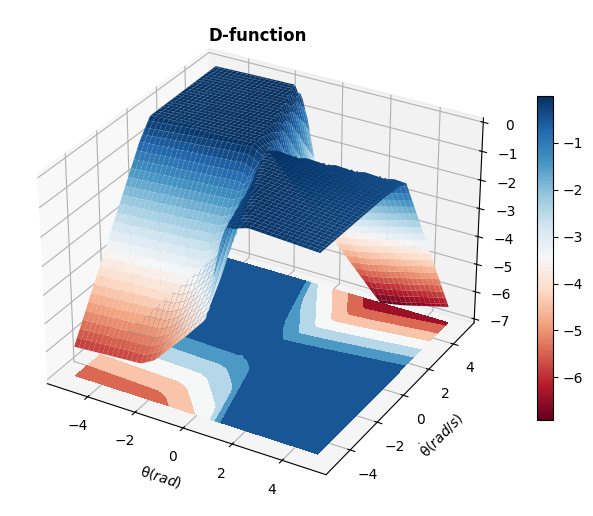

In [7]:
# 初始化动力学模型
params={'m': 2,'L': 1, 'b': 0.1}
controller_params = {'K':np.array([[35, 8]])}
p1 = InvertedPendulum(system_params = params,
                      controller_params = controller_params,
                      dt = 0.01, 
                      controller_period = 0.01)

d1 = DlearningProcess(system=p1,
                      actor_bound=5.0,
                      n_hiddens_policy=16,
                      n_hiddens_lyapunov=16,
                      n_hiddens_dfunction=32,
                      actor_lr=0.001,
                      lyapunov_lr=0.004,
                      dfunction_lr=0.001)

# D learning imitate PPO 控制器
controller_DL_Clip = torch.load('result/DL_Clip/controller_DL_Clip_4.pth',weights_only=False)
lyapunov_DL_Clip = torch.load('result/DL_Clip/lyapunov_DL_Clip_4.pth',weights_only=False)
dfunction_DL_Clip = torch.load('result/DL_Clip/dfunction_DL_Clip_4.pth',weights_only=False)

controller_D_learning = torch.load('result/D_learning/controller_D_learning_2.pth',weights_only=False)
dfunction_D_learning = torch.load('result/D_learning/dfunction_DD_learning_2.pth',weights_only=False)

controller_PPO = torch.load('result/PPO/controller_PPO_4.pth',weights_only=False)
d1.plot_contour_lyapunov_3D(lyapunov = lyapunov_DL_Clip)

d1.plot_contour_dfunction_3D(dfunction = dfunction_DL_Clip,
                        Controller = controller_DL_Clip)


# d1.plot_contour_dfunction_3D(dfunction = dfunction_D_learning,
#                         Controller = controller_D_learning)


-----------------It takes 145 steps to converge.------------------
-----------------It takes 164 steps to converge.------------------


<Figure size 640x480 with 0 Axes>

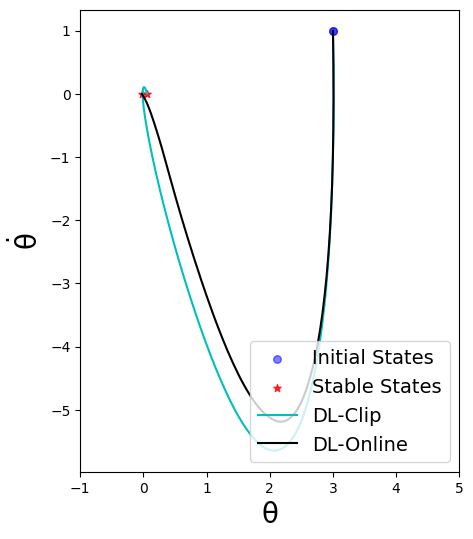

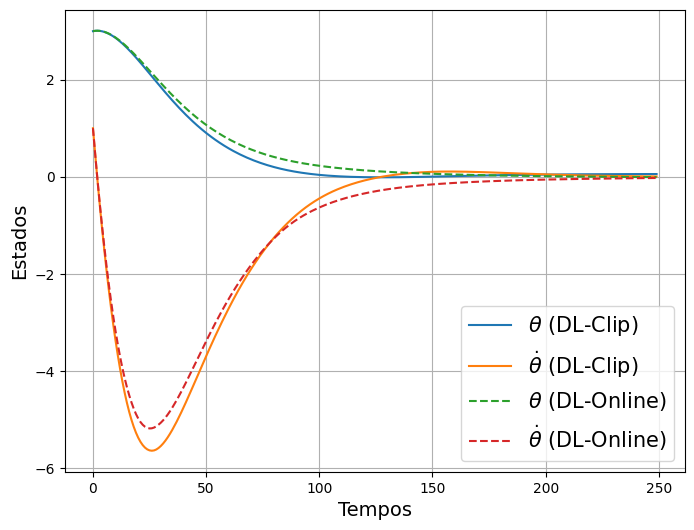

In [8]:
# 以 x_initial 初始点为例 
x_initial = torch.tensor([[3],[1]]).to(device)
step_num = 4000

sim_data_1 = p1.simulate_rk4(x_initial = x_initial, 
                           step_number = step_num,
                           use_controller = 1,
                           the_controller = controller_DL_Clip)
stepconverge_initial1 = p1.convergence_judgment(sim_data_1)

sim_data_2 = p1.simulate_rk4(x_initial = x_initial, 
                           step_number = step_num,
                           use_controller = 1,
                           the_controller = controller_D_learning)
stepconverge_initial2 = p1.convergence_judgment(sim_data_2)


d1.plot_phase_portrait_3(data_sim = sim_data_1,
                       data_sim1 = sim_data_2,
                       arrow_on = False,
                       title = '')

# DL-PPO
s1 = sim_data_1[:,0].cpu().permute(0, 2, 1).squeeze(1)
theta1 = s1[:, 0].cpu().detach().numpy() 
theta_dot1 = s1[:, 1].cpu().detach().numpy() 

# D-learning online
s2 = sim_data_2[:,0].cpu().permute(0, 2, 1).squeeze(1)
theta2 = s2[:, 0].cpu().detach().numpy() 
theta_dot2 = s2[:, 1].cpu().detach().numpy() 

num = 250
plt.figure(figsize=(8, 6))
plt.plot(range(num), theta1[:num], label=r'$\theta$ (DL-Clip)')
plt.plot(range(num), theta_dot1[:num], label=r'$\dot{\theta}$ (DL-Clip)')

plt.plot(range(num), theta2[:num], linestyle='--', label=r'$\theta$ (DL-Online)')
plt.plot(range(num), theta_dot2[:num], linestyle='--', label=r'$\dot{\theta}$ (DL-Online)')

# plt.title('Variation of Data')
plt.xlabel('Tempos',fontsize ='14')
plt.ylabel('Estados',fontsize ='14')
plt.grid(True)  # 添加网格线
plt.legend(loc = 'lower right',fontsize ='15')  # Show legend with added line
plt.show()

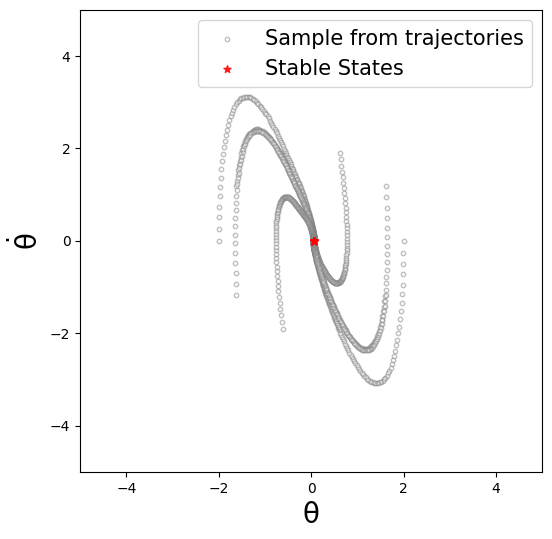

In [86]:
def plot_sampling_lyapunov(
    sample_trajectory_number: int = 10,
    sample_number_per_trajectory: int = 500,
    sample_radius: int = 15,
    sample_number_in_radius: int = 0,
    invariant_sample: bool = True,
    sample_plot: bool = True,
    the_controller=None,
    xlim=5,
    ylim=5,
    lyapunov=None,
    title='Function Contour Plot'
):

    sample_from_trajectory = torch.zeros(sample_trajectory_number * sample_number_per_trajectory, 2, 2, 1).to(d1.device)
    sample_from_radius = torch.zeros(sample_number_in_radius, 2, 2, 1).to(d1.device)
    theta = np.linspace(0, 2 * np.pi, sample_trajectory_number + 1)

    # sample in trajectory
    for i in range(sample_trajectory_number):
        x_0_traj = torch.tensor([[sample_radius * np.cos(theta[i])], [sample_radius * np.sin(theta[i])]],
                                dtype=torch.float).to(d1.device)
        simulate_rk4 = d1.system.simulate_rk4(x_0_traj, sample_number_per_trajectory, 1, the_controller)
        x = simulate_rk4[:, 0].unsqueeze(1)
        x_dot = simulate_rk4[:, 1].unsqueeze(1)
        sample_from_trajectory[i * sample_number_per_trajectory:(i + 1) * sample_number_per_trajectory] = torch.cat(
            (x, x + x_dot * d1.system.dt), dim=1)

    # sample randomly in radius
    if invariant_sample:
        np.random.seed(42)
    theta_ = np.random.uniform(0, 2 * np.pi, sample_number_in_radius)
    r_ = np.sqrt(np.random.uniform(0, sample_radius ** 2, sample_number_in_radius))
    combined_data = zip(theta_, r_)
    i = 0
    for data in combined_data:
        theta__, r__ = data
        x_0_radius = torch.tensor([[r__ * np.cos(theta__)], [r__ * np.sin(theta__)]]).to(d1.device)
        one_step_euler = d1.system.one_step_euler(x_0_radius, 1, the_controller)[1].to(d1.device)
        x = one_step_euler[0].unsqueeze(0)
        x_dot = one_step_euler[1].unsqueeze(0)
        sample_from_radius[i] = torch.cat((x, x + x_dot * d1.system.dt), dim=0)
        i += 1

    plt.figure(figsize=(10, 6))
    plt.ylim(-5, 5)
    plt.xlim(-5, 5)
    plt.xlabel(r"$\mathregular{\theta}$", fontsize=20)
    plt.ylabel(r"$\mathregular{\dot{\theta}}$", fontsize=20)
    
    if sample_plot:
        x1_trajectory = sample_from_trajectory[:, 0, 0, :].cpu().detach().numpy()
        x2_trajectory = sample_from_trajectory[:, 0, 1, :].cpu().detach().numpy()
        plt.scatter(x1_trajectory, x2_trajectory, s=10, alpha=0.5, c='white', edgecolors='gray', label='Sample from trajectories')
        for i in range(0, len(x1_trajectory), sample_number_per_trajectory):
            plt.scatter(x1_trajectory[i + 299], x2_trajectory[i + 299], s=30, alpha=0.8, c='red', marker='*',
                        label='Stable States' if i == 0 else '')
        x1_radius = sample_from_radius[:, 0, 0, :].cpu().detach().numpy()
        x2_radius = sample_from_radius[:, 0, 1, :].cpu().detach().numpy()
        plt.scatter(x1_radius, x2_radius, s=10, alpha=0.5, c='g')
    plt.legend(loc = 'upper right',fontsize ='15')  # Show legend with added line
    plt.gca().set_aspect('equal', adjustable='box')
    # plt.show()
    plt.savefig('result/sampling.png', dpi=300)


plot_sampling_lyapunov(sample_trajectory_number = 10,
        sample_number_per_trajectory = 300,
        sample_radius = 2,
        sample_number_in_radius = 0,
        invariant_sample = 1,
        sample_plot = 1,
        the_controller = controller_DL_Clip,
        lyapunov = lyapunov_DL_Clip,
        title = 'DL-Clip')


In [87]:
# def plot_sampling_lyapunov(
#     sample_trajectory_number: int = 10,
#     sample_number_per_trajectory: int = 500,
#     sample_radius: int = 15,
#     sample_number_in_radius: int = 0,
#     invariant_sample: bool = True,
#     sample_plot: bool = True,
#     the_controller=None,
#     xlim=5,
#     ylim=5,
#     lyapunov=None,
#     title='Function Contour Plot'
# ):
#     x = np.linspace(-xlim, xlim, 100)
#     y = np.linspace(-ylim, ylim, 100)
#     X, Y = np.meshgrid(x, y)
#     Z = np.zeros(X.shape)
#     for i in range(X.shape[0]):
#         for j in range(X.shape[1]):
#             xy = torch.tensor([[X[i, j], Y[i, j]]], dtype=torch.float32)
#             Z[i, j] = lyapunov.V(xy).item()

#     # # Plot contour plot on the same figure
#     plt.figure(figsize=(8, 6))
#     plt.ylim(-5, 5)
#     plt.xlim(-5, 5)
#     plt.xlabel(r"$\mathregular{\theta}$", fontsize=20)
#     plt.ylabel(r"$\mathregular{\dot{\theta}}$", fontsize=20)
#     levels = np.linspace(np.min(Z), np.max(Z), 20)
#     plt.contourf(X, Y, Z, levels=levels, cmap='viridis')
#     plt.colorbar()
#     # cbar = plt.colorbar(label='Lyapunov Function Value')
#     # cbar.ax.set_ylabel('Lyapunov Function Value', fontsize=14)
#     plt.contour(X, Y, Z, levels=[0], colors='blue', linestyles='dashed')
#     plt.xlabel(r"$\theta$", fontsize=20)
#     plt.ylabel(r"$\dot{\theta}$", fontsize=20)
#     plt.title(title, fontsize=20)
#     plt.grid(True)

#     sample_from_trajectory = torch.zeros(sample_trajectory_number * sample_number_per_trajectory, 2, 2, 1).to(d1.device)
#     sample_from_radius = torch.zeros(sample_number_in_radius, 2, 2, 1).to(d1.device)
#     theta = np.linspace(0, 2 * np.pi, sample_trajectory_number + 1)

#     # sample in trajectory
#     for i in range(sample_trajectory_number):
#         x_0_traj = torch.tensor([[sample_radius * np.cos(theta[i])], [sample_radius * np.sin(theta[i])]],
#                                 dtype=torch.float).to(d1.device)
#         simulate_rk4 = d1.system.simulate_rk4(x_0_traj, sample_number_per_trajectory, 1, the_controller)
#         x = simulate_rk4[:, 0].unsqueeze(1)
#         x_dot = simulate_rk4[:, 1].unsqueeze(1)
#         sample_from_trajectory[i * sample_number_per_trajectory:(i + 1) * sample_number_per_trajectory] = torch.cat(
#             (x, x + x_dot * d1.system.dt), dim=1)

#     # sample randomly in radius
#     if invariant_sample:
#         np.random.seed(42)
#     theta_ = np.random.uniform(0, 2 * np.pi, sample_number_in_radius)
#     r_ = np.sqrt(np.random.uniform(0, sample_radius ** 2, sample_number_in_radius))
#     combined_data = zip(theta_, r_)
#     i = 0
#     for data in combined_data:
#         theta__, r__ = data
#         x_0_radius = torch.tensor([[r__ * np.cos(theta__)], [r__ * np.sin(theta__)]]).to(d1.device)
#         one_step_euler = d1.system.one_step_euler(x_0_radius, 1, the_controller)[1].to(d1.device)
#         x = one_step_euler[0].unsqueeze(0)
#         x_dot = one_step_euler[1].unsqueeze(0)
#         sample_from_radius[i] = torch.cat((x, x + x_dot * d1.system.dt), dim=0)
#         i += 1

#     if sample_plot:
#         x1_trajectory = sample_from_trajectory[:, 0, 0, :].cpu().detach().numpy()
#         x2_trajectory = sample_from_trajectory[:, 0, 1, :].cpu().detach().numpy()
#         plt.scatter(x1_trajectory, x2_trajectory, s=10, alpha=0.5, c='white', edgecolors='gray')
#         for i in range(0, len(x1_trajectory), sample_number_per_trajectory):
#             plt.scatter(x1_trajectory[i + 299], x2_trajectory[i + 299], s=30, alpha=0.8, c='red', marker='*',
#                         label='' if i == 0 else '')
#         x1_radius = sample_from_radius[:, 0, 0, :].cpu().detach().numpy()
#         x2_radius = sample_from_radius[:, 0, 1, :].cpu().detach().numpy()
#         plt.scatter(x1_radius, x2_radius, s=10, alpha=0.5, c='g')
#     # plt.legend(loc = 'upper right',fontsize ='15')  # Show legend with added line
#     # plt.gca().set_aspect('equal', adjustable='box')
#     # plt.show()
#     plt.savefig('result/sampling.png')

# plot_sampling_lyapunov(sample_trajectory_number = 10,
#         sample_number_per_trajectory = 300,
#         sample_radius = 2,
#         sample_number_in_radius = 0,
#         invariant_sample = 1,
#         sample_plot = 1,
#         the_controller = controller_Dlearning_PPO,
#         lyapunov = lyapunov_Dlearning_PPO,
#         title = 'DL-Clip')


In [88]:
# def plot_sampling_dfunction(
#     sample_trajectory_number: int = 10,
#     sample_number_per_trajectory: int = 500,
#     sample_radius: int = 15,
#     sample_number_in_radius: int = 0,
#     invariant_sample: bool = True,
#     sample_plot: bool = True,
#     the_controller=None,
#     xlim=5,
#     ylim=5,
#     dfunction=None,
#     title='Function Contour Plot'
# ):
#     x = np.linspace(-xlim, xlim, 100)
#     y = np.linspace(-ylim, ylim, 100)
#     X, Y = np.meshgrid(x, y)
#     Z = np.zeros(X.shape)
#     for i in range(X.shape[0]):
#         for j in range(X.shape[1]):
#             xy = torch.tensor([[X[i, j], Y[i, j]]], dtype=torch.float32)
#             Z[i, j] = dfunction.D(xy,the_controller(xy.t())).item()  # Compute Lyapunov function value

#     # # Plot contour plot on the same figure
#     plt.figure(figsize=(8, 6))
#     plt.ylim(-5, 5)
#     plt.xlim(-5, 5)
#     plt.xlabel(r"$\mathregular{\theta}$")
#     plt.ylabel(r"$\mathregular{\dot{\theta}}$")
#     levels = np.linspace(np.min(Z), np.max(Z), 20)
#     plt.contourf(X, Y, Z, levels=levels, cmap='viridis')
#     plt.colorbar(label='D-function Value')
#     plt.contour(X, Y, Z, levels=[0], colors='blue', linestyles='dashed')
#     plt.xlabel(r"$\theta$")
#     plt.ylabel(r"$\dot{\theta}$")
#     plt.title(title)
#     plt.grid(True)

#     sample_from_trajectory = torch.zeros(sample_trajectory_number * sample_number_per_trajectory, 2, 2, 1).to(d1.device)
#     sample_from_radius = torch.zeros(sample_number_in_radius, 2, 2, 1).to(d1.device)
#     theta = np.linspace(0, 2 * np.pi, sample_trajectory_number + 1)

#     # sample in trajectory
#     for i in range(sample_trajectory_number):
#         x_0_traj = torch.tensor([[sample_radius * np.cos(theta[i])], [sample_radius * np.sin(theta[i])]],
#                                 dtype=torch.float).to(d1.device)
#         simulate_rk4 = d1.system.simulate_rk4(x_0_traj, sample_number_per_trajectory, 1, the_controller)
#         x = simulate_rk4[:, 0].unsqueeze(1)
#         x_dot = simulate_rk4[:, 1].unsqueeze(1)
#         sample_from_trajectory[i * sample_number_per_trajectory:(i + 1) * sample_number_per_trajectory] = torch.cat(
#             (x, x + x_dot * d1.system.dt), dim=1)

#     # sample randomly in radius
#     if invariant_sample:
#         np.random.seed(42)
#     theta_ = np.random.uniform(0, 2 * np.pi, sample_number_in_radius)
#     r_ = np.sqrt(np.random.uniform(0, sample_radius ** 2, sample_number_in_radius))
#     combined_data = zip(theta_, r_)
#     i = 0
#     for data in combined_data:
#         theta__, r__ = data
#         x_0_radius = torch.tensor([[r__ * np.cos(theta__)], [r__ * np.sin(theta__)]]).to(d1.device)
#         one_step_euler = d1.system.one_step_euler(x_0_radius, 1, the_controller)[1].to(d1.device)
#         x = one_step_euler[0].unsqueeze(0)
#         x_dot = one_step_euler[1].unsqueeze(0)
#         sample_from_radius[i] = torch.cat((x, x + x_dot * d1.system.dt), dim=0)
#         i += 1

#     if sample_plot:
#         x1_trajectory = sample_from_trajectory[:, 0, 0, :].cpu().detach().numpy()
#         x2_trajectory = sample_from_trajectory[:, 0, 1, :].cpu().detach().numpy()
#         plt.scatter(x1_trajectory, x2_trajectory, s=10, alpha=0.5, c='white', edgecolors='gray', label='Sample from trajectories')
#         for i in range(0, len(x1_trajectory), sample_number_per_trajectory):
#             plt.scatter(x1_trajectory[i + 199], x2_trajectory[i + 199], s=30, alpha=0.8, c='red', marker='*',
#                         label='Stable States' if i == 0 else '')

#         x1_radius = sample_from_radius[:, 0, 0, :].cpu().detach().numpy()
#         x2_radius = sample_from_radius[:, 0, 1, :].cpu().detach().numpy()
#         plt.scatter(x1_radius, x2_radius, s=10, alpha=0.5, c='g')
#     plt.legend(loc = 'upper right',fontsize ='12')  # Show legend with added line
#     plt.gca().set_aspect('equal', adjustable='box')
#     # plt.show()
#     plt.savefig('result/sampling.png')

# plot_sampling_dfunction(sample_trajectory_number = 10,
#         sample_number_per_trajectory = 300,
#         sample_radius = 2,
#         sample_number_in_radius = 0,
#         invariant_sample = 1,
#         sample_plot = 1,
#         the_controller = controller_Dlearning_PPO,
#         dfunction = dfunction_Dlearning_PPO,
#         title = 'DL-Clip')


In [89]:
# LQR
# params={'m': 2,'L': 1, 'b': 0.1}
# controller_params = {'K':np.array([[35, 8]])}

# p1 = InvertedPendulum(system_params = params,
#                       controller_params = controller_params,
#                       dt = 0.01, 
#                       controller_period = 0.01)

# p1.linearize_and_compute_LQR()
# x_initial = torch.tensor([[3],[1]]).to(device)
# step_num = 4000
# sim_data_ = p1.simulate_rk4(x_initial, step_num, 1,)
# p1.convergence_judgment(sim_data_)
# p1.plot_phase_portrait(data_sim = sim_data_,
#                        arrow_on = False,
#                        title = 'System Phase Portrait with initial controller')

# controller_params = {'K':np.array([[39.22549439, 12.46630326]])} # LQR
stepconverge_LQR = 147

# Controller is involved.
# tensor([0., 0.])
# linearized_ct_system:
#  A[[ 0.    1.  ]
#  [ 9.8  -0.05]],
#  B[[0. ]
#  [0.5]]
# computed LQR controller is [[39.22549439 12.46630326]]
# -----------------It takes 147 steps to converge.------------------

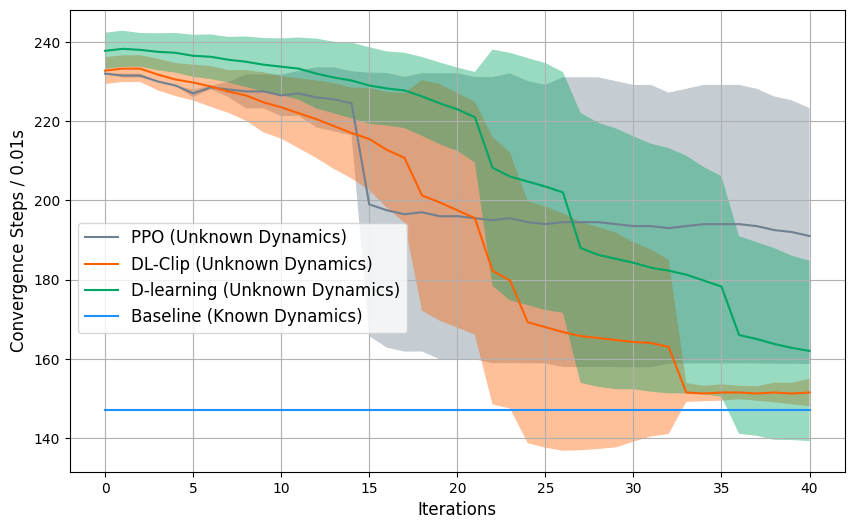

1923.75
1176.3323442338353
1440.5953543382955
151.5
162.0
191.0


In [90]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# 加载数据
with open('result/D_learning/stepconverge_list_controller_D_learning_1.pk', 'rb') as f:
    stepconverge_list_Dlearning_1 = pickle.load(f)

with open('result/D_learning/stepconverge_list_controller_D_learning_5.pk', 'rb') as f:
    stepconverge_list_Dlearning_2 = pickle.load(f)
stepconverge_list_Dlearning_2 = stepconverge_list_Dlearning_2[:41]
with open('result/D_learning/stepconverge_list_controller_D_learning_3.pk', 'rb') as f:
    stepconverge_list_Dlearning_3 = pickle.load(f)

with open('result/D_learning/stepconverge_list_controller_D_learning_4.pk', 'rb') as f:
    stepconverge_list_Dlearning_4 = pickle.load(f)

# 将数据整理为数组
stepconverge_data = np.array([
    stepconverge_list_Dlearning_1,
    stepconverge_list_Dlearning_2,
    stepconverge_list_Dlearning_3,
    stepconverge_list_Dlearning_4
])

# 计算均值和标准差
mean_stepconverge = np.mean(stepconverge_data, axis=0)
std_stepconverge = np.std(stepconverge_data, axis=0)

# 计算上下边界
upper_bound = mean_stepconverge + std_stepconverge * 0.95
lower_bound = mean_stepconverge - std_stepconverge * 0.95

# 生成 x 轴数据
x = np.arange(len(mean_stepconverge))
#########################################################################################
# 加载数据
with open('result/DL_Clip/stepconverge_list_controller_DL_Clip_1.pk', 'rb') as f:
    stepconverge_list_DLClip_1 = pickle.load(f)

with open('result/DL_Clip/stepconverge_list_controller_DL_Clip_2.pk', 'rb') as f:
    stepconverge_list_DLClip_2 = pickle.load(f)

with open('result/DL_Clip/stepconverge_list_controller_DL_Clip_5.pk', 'rb') as f:
    stepconverge_list_DLClip_5 = pickle.load(f)
    
with open('result/DL_Clip/stepconverge_list_controller_DL_Clip_3.pk', 'rb') as f:
    stepconverge_list_DLClip_3 = pickle.load(f)
    
# 将数据整理为数组
stepconverge_data_DLClip = np.array([
    stepconverge_list_DLClip_1,
    stepconverge_list_DLClip_2,
    stepconverge_list_DLClip_5,
    stepconverge_list_DLClip_3
])
# 把240多的删掉

# 计算均值和标准差
mean_stepconverge_DLClip = np.mean(stepconverge_data_DLClip, axis=0)
std_stepconverge_DLClip = np.std(stepconverge_data_DLClip, axis=0)

# 计算上下边界
upper_bound_DLClip = mean_stepconverge_DLClip + std_stepconverge_DLClip * 0.95
lower_bound_DLClip = mean_stepconverge_DLClip - std_stepconverge_DLClip * 0.95
######################################################################
# 加载数据
with open('result/PPO/stepconverge_list_controller_PPO_4.pk', 'rb') as f:
    stepconverge_list_PPO1 = pickle.load(f)
with open('result/PPO/stepconverge_list_controller_PPO_6.pk', 'rb') as f:
    stepconverge_list_PPO6 = pickle.load(f)
       
# 将数据整理为数组
stepconverge_data_PPO = np.array([
    stepconverge_list_PPO1,
    stepconverge_list_PPO6,
])
# 把240多的删掉

# 计算均值和标准差
mean_stepconverge_PPO = np.mean(stepconverge_data_PPO, axis=0)
std_stepconverge_PPO = np.std(stepconverge_data_PPO, axis=0)

# 计算上下边界
upper_bound_PPO = mean_stepconverge_PPO + std_stepconverge_PPO * 0.95
lower_bound_PPO = mean_stepconverge_PPO - std_stepconverge_PPO * 0.95
#########################################################################
# 生成 x 轴数据
x = np.arange(len(mean_stepconverge_DLClip))

# 绘图
plt.figure(figsize=(10, 6))

plt.plot(x, mean_stepconverge_PPO, label='PPO (Unknown Dynamics)', color='#708090')
plt.fill_between(x, upper_bound_PPO, lower_bound_PPO, alpha=0.4, facecolor='#708090')

plt.plot(x, mean_stepconverge_DLClip, label='DL-Clip (Unknown Dynamics)', color='#FF6100')
plt.fill_between(x, upper_bound_DLClip, lower_bound_DLClip, alpha=0.4, facecolor='#FF6100')

plt.plot(x, mean_stepconverge, label='D-learning (Unknown Dynamics)', color='#00A664')
plt.fill_between(x, upper_bound, lower_bound, alpha=0.4, facecolor='#00A664')

stepconverge_LQR = 147
plt.plot([0, len(mean_stepconverge_DLClip)-1], [stepconverge_LQR, stepconverge_LQR], color='#1E90FF', label='Baseline (Known Dynamics)')
# 添加标签和图例
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Convergence Steps / 0.01s', fontsize=12)
plt.legend(fontsize ='12', loc='center left',bbox_to_anchor=(0.0, 0.42))  # Show legend with added line
plt.grid(True)
plt.savefig('result/contrast.png', dpi=300)
plt.show()

print(sum(upper_bound_PPO-lower_bound_PPO))
print(sum(upper_bound_DLClip-lower_bound_DLClip))
print(sum(upper_bound-lower_bound))
print(mean_stepconverge_DLClip[40])
print(mean_stepconverge[40])
print(mean_stepconverge_PPO[40])

MovieWriter imagemagick unavailable; using Pillow instead.


-----------------It takes 154 steps to converge.------------------


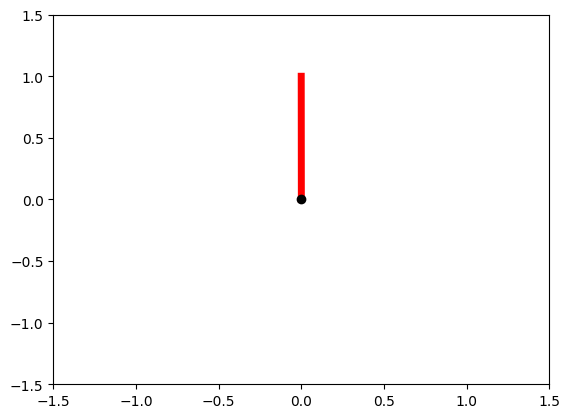

In [91]:
# 绘制 DL-Clip 和 D-learning 的 gif 图

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import torch

# 假设 device 已经定义
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 加载控制器
# controller = torch.load('result/D_learning/controller_D_learning_2.pth', weights_only=False)
controller = torch.load('result/DL_Clip/controller_DL_Clip_3.pth', weights_only=False)

# 初始状态
x_initial = torch.tensor([[3], [1]]).to(device)

# 模拟参数
step_num = 4000
sim_data_ = p1.simulate_rk4(x_initial=x_initial, 
                            step_number=step_num,
                            use_controller=1,
                            the_controller=controller)

# 判断收敛性
stepconverge = p1.convergence_judgment(sim_data_)

# 处理模拟数据
sim_data_ = sim_data_.detach().clone()
s = sim_data_[:, 0].permute(0, 2, 1).squeeze(1)
theta = s[:, 0]
theta = theta[:200]

# 创建新的张量并移动到 GPU
new_element1 = torch.tensor([3e-02], dtype=torch.float32).to(device)
new_element2 = torch.tensor([1.7112e-02], dtype=torch.float32).to(device)
new_element3 = torch.tensor([9.1330e-03], dtype=torch.float32).to(device)
new_element4 = torch.tensor([7.3696e-04], dtype=torch.float32).to(device)

# 将新张量连接到 theta
theta = torch.cat((theta, new_element1))
theta = torch.cat((theta, new_element2))
theta = torch.cat((theta, new_element3))
theta = torch.cat((theta, new_element4))

# 计算 x 和 y
x = -np.sin(theta.cpu().numpy())  # 将 theta 移动到 CPU 并转换为 NumPy 数组
y = np.cos(theta.cpu().numpy())  # 将 theta 移动到 CPU 并转换为 NumPy 数组

# 初始化绘图
fig, ax = plt.subplots()
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
line, = ax.plot([], [], color='red', linewidth=5.0)
point, = ax.plot([], [], 'ko')  # 蓝色点

# 初始化函数：绘制每一帧的背景
def init():
    line.set_data([], [])
    point.set_data([], [])
    return line, point

# 动画函数：按顺序调用
def update(frame):
    if frame < len(x):
        # 更新线的位置
        line.set_data([0, x[frame]], [0, y[frame]])
        # 更新点的位置
        point.set_data([0], [0])
    return line, point

# 动画帧数
frames = len(x)

# 创建动画
ani = FuncAnimation(fig, update, frames=frames, init_func=init, blit=True, interval=50)

# 保存为 GIF
# ani.save('result/D-learning.gif', writer='imagemagick', fps=15)
ani.save('result/DL_Clip.gif', writer='imagemagick', fps=15)

# 显示动画
plt.show()

MovieWriter imagemagick unavailable; using Pillow instead.


-----------------It takes 243 steps to converge.------------------


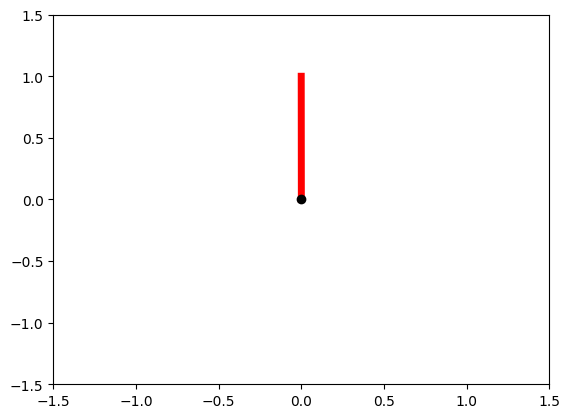

In [11]:
# 生成 PPO.gif, 不用 CUDA 环境跑，用 D_learning 环境跑
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import torch

# 假设 device 已经定义
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 加载控制器
controller = torch.load('result/PPO/controller_PPO_4.pth', weights_only=False)

# 初始状态
x_initial = torch.tensor([[3], [1]]).to(device)

# 模拟参数
step_num = 4000
sim_data_ = p1.simulate_rk4(x_initial=x_initial, 
                            step_number=step_num,
                            use_controller=1,
                            the_controller=controller)

# 判断收敛性
stepconverge = p1.convergence_judgment(sim_data_)

# 处理模拟数据
sim_data_ = sim_data_.detach().clone()
s = sim_data_[:, 0].permute(0, 2, 1).squeeze(1)
theta = s[:, 0]
theta = theta[:243]

# 创建新的张量并移动到 GPU
new_element1 = torch.tensor([3e-02], dtype=torch.float32).to(device)
new_element2 = torch.tensor([1.7112e-02], dtype=torch.float32).to(device)
new_element3 = torch.tensor([9.1330e-03], dtype=torch.float32).to(device)
new_element4 = torch.tensor([7.3696e-04], dtype=torch.float32).to(device)

# 将新张量连接到 theta
theta = torch.cat((theta, new_element1))
theta = torch.cat((theta, new_element2))
theta = torch.cat((theta, new_element3))
theta = torch.cat((theta, new_element4))

# 计算 x 和 y
x = -np.sin(theta.cpu().numpy())  # 将 theta 移动到 CPU 并转换为 NumPy 数组
y = np.cos(theta.cpu().numpy())  # 将 theta 移动到 CPU 并转换为 NumPy 数组

# 初始化绘图
fig, ax = plt.subplots()
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
line, = ax.plot([], [], color='red', linewidth=5.0)
point, = ax.plot([], [], 'ko')  # 蓝色点

# 初始化函数：绘制每一帧的背景
def init():
    line.set_data([], [])
    point.set_data([], [])
    return line, point

# 动画函数：按顺序调用
def update(frame):
    if frame < len(x):
        # 更新线的位置
        line.set_data([0, x[frame]], [0, y[frame]])
        # 更新点的位置
        point.set_data([0], [0])
    return line, point

# 动画帧数
frames = len(x)

# 创建动画
ani = FuncAnimation(fig, update, frames=frames, init_func=init, blit=True, interval=50)

# 保存为 GIF
ani.save('result/PPO.gif', writer='imagemagick', fps=15)

# 显示动画
plt.show()

In [ ]:
print('----------------------Comparison----------------------')
# 读取保存的 stepconverge_list 文件
# with open('result/DL_Clip/stepconverge_list_controller_DL_Clip_4.pk', 'rb') as f:
# with open('result/DL_Clip/stepconverge_list_controller_DL_Clip_1.pk', 'rb') as f:
with open('result/PPO/stepconverge_list_controller_PPO_4.pk', 'rb') as f:
    stepconverge_list__Dlearning_PPO = pickle.load(f)

    
# 绘制 stepconverge 值随迭代次数变化的折线图
plt.figure()
plt.plot(range(0, len(stepconverge_list__Dlearning_PPO)), stepconverge_list__Dlearning_PPO, marker='o',label='DL-Clip')
plt.xlabel('Iterations', fontsize=15)
plt.ylabel('Convergence Steps', fontsize=15)
plt.grid(True)
plt.legend(loc = 'upper right',fontsize ='15')  # Show legend with added line
print(stepconverge_list__Dlearning_PPO[40])

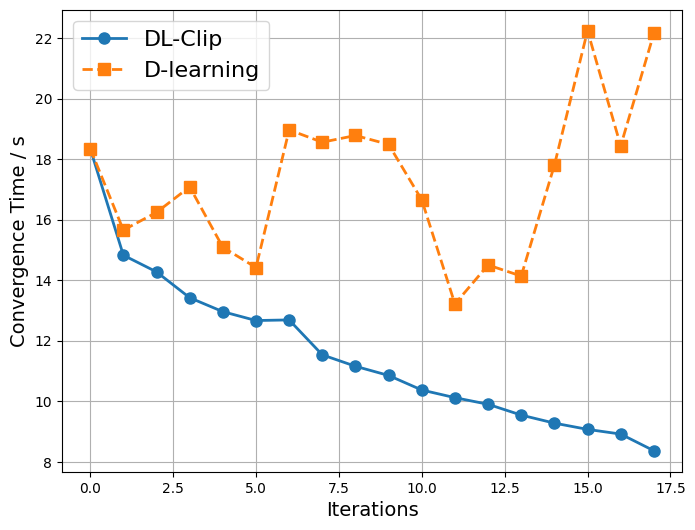

In [ ]:
import time
import subprocess
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
# DL-Online Iteration Dataset
output_parent = './DL-Clip_dataset/'

output_files = os.listdir(output_parent)
output_files = sorted(output_files, key=lambda x: os.path.getmtime(os.path.join(output_parent, x)))
output_files = output_files[::-1] # Depends on when the data was created
length_array = np.zeros((18))
j = 17
nnn = 17 # 0-17
test=0 # 0-10
for output_file in output_files:
    output_dataset_dir = output_parent + output_file
    len_sum = 0.0
    for i in range(10):
        filename =  output_dataset_dir + '/cwp_dataengine_{}.csv'.format(str(i))
        if not os.path.exists(filename):
            break
        stateDataAll1 = np.loadtxt(open(filename,"rb"),delimiter=",",skiprows=1)
        if j == nnn and i == test:
            stateDataAll_clip = np.loadtxt(open(filename,"rb"),delimiter=",",skiprows=1)
            time_clip = stateDataAll_clip[-1,18] - stateDataAll_clip[0,18]
        len_sum = len_sum + stateDataAll1[-1,18] - stateDataAll1[0,18]
    # print(output_file, len_sum / 10.0 )

    length_array[j] = len_sum / 10.0
    j = j - 1

plt.figure(figsize=(8, 6))  # 设置图表大小
# 绘制曲线，使用不同的线条样式和颜色
plt.plot(length_array,  marker='o', linestyle='-', label='DL-Clip', markersize=8, linewidth=2)

# DL-Online Iteration Dataset
output_parent = './DL-Online_dataset/'

output_files = os.listdir(output_parent)
output_files = sorted(output_files, key=lambda x: os.path.getmtime(os.path.join(output_parent, x)))
output_files = output_files[::-1] # Depends on when the data was created
length_array = np.zeros((18))
j = 17

for output_file in output_files:
    output_dataset_dir = output_parent + output_file
    len_sum = 0.0
    for i in range(10):
        filename =  output_dataset_dir + '/cwp_dataengine_{}.csv'.format(str(i))
        if not os.path.exists(filename):
            break
        stateDataAll1 = np.loadtxt(open(filename,"rb"),delimiter=",",skiprows=1)
        if j == nnn and i == test:
            stateDataAll_online = np.loadtxt(open(filename,"rb"),delimiter=",",skiprows=1)
            time_online = stateDataAll_online[-1,18] - stateDataAll_online[0,18]
        len_sum = len_sum + stateDataAll1[-1,18] - stateDataAll1[0,18]
    # print(output_file, len_sum / 10.0 )

    length_array[j] = len_sum / 10.0
    j = j - 1
    


plt.plot(length_array,  marker='s', linestyle='--', label='D-learning', markersize=8, linewidth=2)
# 设置标题和标签
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Convergence Time / s', fontsize=14)
# 设置图例
plt.legend(fontsize=16, loc='upper left')  # 将图例放置在右上角

# 设置网格样式
plt.grid(True)


# 保存图表
plt.savefig('result/IBVS_fig1.png', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()

stateDataAll_clip shape: (103, 51)
stateDataAll_online shape: (335, 51)
speed_clip min/max: 0.4012848877224318 4.6658348962959995
speed_online min/max: 0.30274108176896897 1.8634198635609336


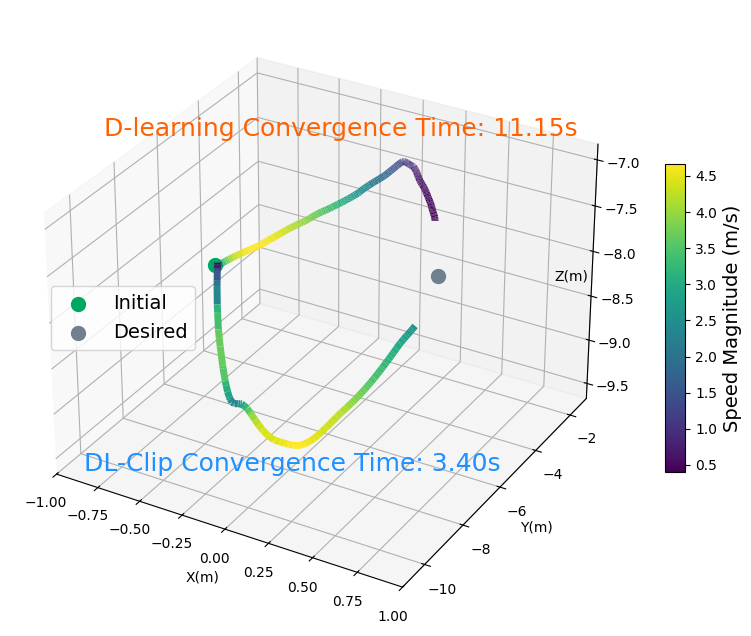

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
# DL-Online Iteration Dataset
output_parent = './DL-Clip_dataset/'

output_files = os.listdir(output_parent)
output_files = sorted(output_files, key=lambda x: os.path.getmtime(os.path.join(output_parent, x)))
output_files = output_files[::-1] # Depends on when the data was created
length_array = np.zeros((18))
j = 17
nnn = 17 # 0-17
test=0 # 0-10
for output_file in output_files:
    output_dataset_dir = output_parent + output_file
    len_sum = 0.0
    for i in range(10):
        filename =  output_dataset_dir + '/cwp_dataengine_{}.csv'.format(str(i))
        if not os.path.exists(filename):
            break
        stateDataAll1 = np.loadtxt(open(filename,"rb"),delimiter=",",skiprows=1)
        if j == nnn and i == test:
            stateDataAll_clip = np.loadtxt(open(filename,"rb"),delimiter=",",skiprows=1)
            time_clip = stateDataAll_clip[-1,18] - stateDataAll_clip[0,18]
        len_sum = len_sum + stateDataAll1[-1,18] - stateDataAll1[0,18]

    length_array[j] = len_sum / 10.0
    j = j - 1

# DL-Online Iteration Dataset
output_parent = './DL-Online_dataset/'

output_files = os.listdir(output_parent)
output_files = sorted(output_files, key=lambda x: os.path.getmtime(os.path.join(output_parent, x)))
output_files = output_files[::-1] # Depends on when the data was created
length_array = np.zeros((18))
j = 17

for output_file in output_files:
    output_dataset_dir = output_parent + output_file
    len_sum = 0.0
    for i in range(10):
        filename =  output_dataset_dir + '/cwp_dataengine_{}.csv'.format(str(i))
        if not os.path.exists(filename):
            break
        stateDataAll1 = np.loadtxt(open(filename,"rb"),delimiter=",",skiprows=1)
        if j == nnn and i == test:
            stateDataAll_online = np.loadtxt(open(filename,"rb"),delimiter=",",skiprows=1)
            time_online = stateDataAll_online[-1,18] - stateDataAll_online[0,18]
        len_sum = len_sum + stateDataAll1[-1,18] - stateDataAll1[0,18]

    length_array[j] = len_sum / 10.0
    j = j - 1

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection

# 加载数据（假设数据已正确加载）
# stateDataAll_clip 和 stateDataAll_online 是 (N, M) 的数组，M >= 6

# 提取速度分量
vx_clip = stateDataAll_clip[:, 3]  # x 轴速度
vy_clip = stateDataAll_clip[:, 4]  # y 轴速度
vz_clip = stateDataAll_clip[:, 5]  # z 轴速度
speed_clip = np.sqrt(vx_clip**2 + vy_clip**2 + vz_clip**2)

vx_online = stateDataAll_online[:, 3]  # x 轴速度
vy_online = stateDataAll_online[:, 4]  # y 轴速度
vz_online = stateDataAll_online[:, 5]  # z 轴速度
speed_online = np.sqrt(vx_online**2 + vy_online**2 + vz_online**2)

# 检查数据
print("stateDataAll_clip shape:", stateDataAll_clip.shape)
print("stateDataAll_online shape:", stateDataAll_online.shape)
print("speed_clip min/max:", np.min(speed_clip), np.max(speed_clip))
print("speed_online min/max:", np.min(speed_online), np.max(speed_online))

# 创建图形
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 定义颜色映射
cmap = plt.get_cmap('viridis')  # 使用更美观的颜色映射

# 绘制 DL-Clip 轨迹
points_clip = np.array([stateDataAll_clip[:, 0], stateDataAll_clip[:, 1], stateDataAll_clip[:, 2]]).T.reshape(-1, 1, 3)
segments_clip = np.concatenate([points_clip[:-1], points_clip[1:]], axis=1)
lc_clip = Line3DCollection(segments_clip, cmap=cmap, norm=Normalize(vmin=np.min(speed_clip), vmax=np.max(speed_clip)))
lc_clip.set_array(speed_clip)
lc_clip.set_linewidth(5)  # 加粗线条
ax.add_collection(lc_clip)

# 绘制 D-learning 轨迹
points_online = np.array([stateDataAll_online[:, 0], stateDataAll_online[:, 1], stateDataAll_online[:, 2]]).T.reshape(-1, 1, 3)
segments_online = np.concatenate([points_online[:-1], points_online[1:]], axis=1)
lc_online = Line3DCollection(segments_online, cmap=cmap, norm=Normalize(vmin=np.min(speed_online), vmax=np.max(speed_online)))
lc_online.set_array(speed_online)
lc_online.set_linewidth(5)
ax.add_collection(lc_online)

# 设置坐标轴范围
ax.set_xlim([np.min(stateDataAll_clip[:, 0]), np.max(stateDataAll_clip[:, 0])])
ax.set_ylim([np.min(stateDataAll_clip[:, 1]), np.max(stateDataAll_clip[:, 1])])
ax.set_zlim([np.min(stateDataAll_clip[:, 2]), np.max(stateDataAll_clip[:, 2])])
ax.set_xlim([-1.0, 1.0])

# 添加标签
ax.set_xlabel('X(m)', fontsize=10)
ax.set_ylabel('Y(m)', fontsize=10)
ax.set_zlabel('Z(m)', fontsize=10, labelpad=-30)  # 使用负值 labelpad

# 在轨迹上方添加时间信息
ax.text(stateDataAll_clip[0, 0]-0.82, stateDataAll_clip[0, 1], stateDataAll_clip[0, 2] - 2.7,  # 调整文本位置
        f'DL-Clip Convergence Time: {time_clip:.2f}s', color='#1E90FF', fontsize=18)
ax.text(stateDataAll_online[0, 0]-0.6, stateDataAll_online[0, 1], stateDataAll_online[0, 2] + 1,  # 调整文本位置
        f'D-learning Convergence Time: {time_online:.2f}s', color='#FF6100', fontsize=18)

# 在 D-learning 轨迹的起始点添加标注
ax.scatter(stateDataAll_online[0, 0], stateDataAll_online[0, 1], stateDataAll_online[0, 2], 
           color='#00A664', s=100, label='Initial') 
ax.scatter(0, 0, -9, 
           color='#708090', s=100, label='Desired')  

# 添加颜色条
cbar = fig.colorbar(lc_clip, ax=ax, shrink=0.5, aspect=15)
cbar.set_label('Speed Magnitude (m/s)', fontsize=14)

# 添加图例
ax.legend(fontsize=14, bbox_to_anchor=(0.05, 0.5), loc='center left')
# 保存图表
plt.savefig('result/IBVS_fig2.png', dpi=300, bbox_inches='tight')

# 显示图形
plt.show()